# Task description

- Model wine quality using Xavier vs. Kamming initialization on the weights (use default initialization for the biases)
- Can be staretd with: DUDL_measurePerformance_APRFexample1.ipynb
- Run both models x10 each, visualize performance, and run a t-test to compare

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import scipy.stats as stats
import sklearn.metrics as skm
import torch.nn.functional as F

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [2]:
# import the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url,sep=';')
data = data[data['total sulfur dioxide']<200] # drop a few outliers

# z-score all columns except for quality
cols2zscore = data.keys()
cols2zscore = cols2zscore.drop('quality')
data[cols2zscore] = data[cols2zscore].apply(stats.zscore)

# create a new column for binarized (boolean) quality
data['boolQuality'] = 0
# data['boolQuality'][data['quality']<6] = 0 # implicit in the code! just here for clarity
data.loc[data['quality']>5,'boolQuality'] = 1

In [3]:
# convert from pandas dataframe to tensor
dataT  = torch.tensor( data[cols2zscore].values ).float()
labels = torch.tensor( data['boolQuality'].values ).float()
labels = labels[:,None] # transform to matrix

# use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labels, test_size=.1)

# then convert them into PyTorch Datasets (note: already converted to tensors)
train_dataDataset = torch.utils.data.TensorDataset(train_data,train_labels)
test_dataDataset  = torch.utils.data.TensorDataset(test_data,test_labels)

# finally, create dataloaders
train_loader = DataLoader(train_dataDataset,batch_size=32, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_dataDataset,batch_size=test_dataDataset.tensors[0].shape[0])

# Now for the DL part

In [4]:
# create a class for the model

def createWineNet(in_features:int=11, out_features:int=1, lr:float=1e-2, weights_init_type:str='Xavier'):
  '''
  Create a feedforward neural network for the wine quality dataset with specified weight initialization.
  Args:
    in_features (int): Number of input features.
    out_features (int): Number of output features.
    lr (float): Learning rate for the optimizer.
    weights_init_type (str): Type of weight initialization ('Xavier' or 'Kaiming').
  Returns:
    net (nn.Module): The neural network model.
    lossfun (nn.Module): The loss function.
    optimizer (torch.optim.Optimizer): The optimizer.
  '''
  
  class ANNwine(nn.Module):
    def __init__(self):
      super().__init__()

      self.input = nn.Linear(in_features,16)
      self.fc1 = nn.Linear(self.input.out_features,32)
      self.fc2 = nn.Linear(self.fc1.out_features,32)
      self.output = nn.Linear(self.fc2.out_features,out_features)
      
      # Xavier initialization
      if weights_init_type == 'Xavier':
        nn.init.xavier_uniform_(self.input.weight)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.output.weight)
      elif weights_init_type == 'Kaiming':
        nn.init.kaiming_uniform_(self.input.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.output.weight, nonlinearity='relu')
      else:
        raise ValueError("weights_init_type must be either 'Xavier' or 'Kaiming'")

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)
    
    @staticmethod
    @torch.no_grad()
    def accuracy(yHat, y):
      return torch.mean(((yHat>0) == y).float()).item()
    
  net = ANNwine()
  lossfun = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(),lr=lr)
  
  return net, lossfun, optimizer

In [5]:
# Dummy net creation and test
net, lossfun, optimizer = createWineNet()
X, y = next(iter(train_loader))
yHat = net(X)
loss = lossfun(yHat,y)
acc = net.accuracy(yHat,y)
print(f'Loss: {loss.item():.4f}, Acc: {acc:.4f}')

Loss: 0.6633, Acc: 0.6562


# A function to train the model

In [6]:
# global parameter
def trainTheModel(net, lossfun, optimizer, numepochs:int=1000):  
  # initialize losses
  losses   = torch.zeros(numepochs)
  trainAcc = []
  testAcc  = []

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    
    net.train() # set the model to training mode
    
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())
      batchAcc.append( 100*net.accuracy(yHat,y) )
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    net.eval() # set the model to evaluation mode
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      testAcc.append( 100*net.accuracy(yHat,y) )

  # function output
  return trainAcc,testAcc,losses

# Train the models

In [7]:
# Init and train x10 models with Xavier and x10 models with Kaiming weights initialization over 600 epochs each

numepochs = 600  # use 600 
num_repeats = 10

net_dict = {
    'Xavier': {'net': [None]*num_repeats, 'trainAcc': np.zeros((num_repeats, numepochs)), 'testAcc': np.zeros((num_repeats, numepochs)), 'losses': np.zeros((num_repeats, numepochs))},
    'Kaiming': {'net': [None]*num_repeats, 'trainAcc': np.zeros((num_repeats, numepochs)), 'testAcc': np.zeros((num_repeats, numepochs)), 'losses': np.zeros((num_repeats, numepochs))}
}

for i in range(num_repeats):
    for init_type in net_dict.keys():
        net_dict[init_type]['net'][i], lossfun, optimizer = createWineNet(weights_init_type=init_type, lr=1e-4)
        net_dict[init_type]['trainAcc'][i,:], net_dict[init_type]['testAcc'][i,:], net_dict[init_type]['losses'][i,:] = trainTheModel(
                                                    net_dict[init_type]['net'][i], lossfun, optimizer, numepochs=numepochs)

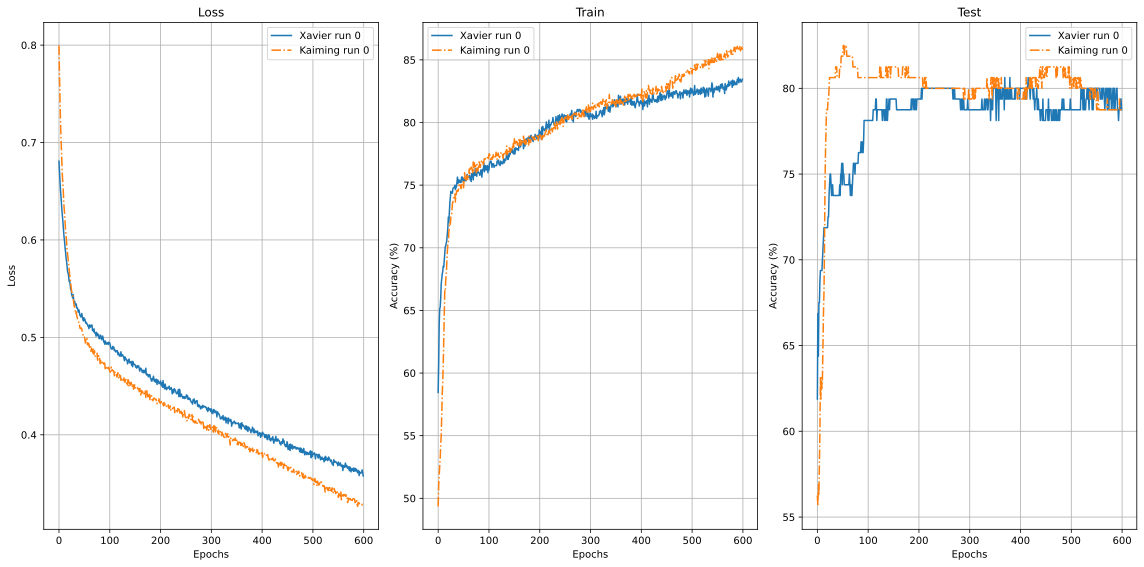

In [48]:
# Show loss and accuracy curves
fig,axs = plt.subplots(1,3,figsize=(16,8))

for i in range(1):
  for init_type in net_dict.keys():
      label = f'{init_type} run {i}'
      linestyle = '-' if init_type=='Xavier' else '-.'
      axs[0].plot(net_dict[init_type]['losses'][i,:], label=label, linestyle=linestyle)
      axs[0].set_title('Loss')
      axs[0].set_ylabel('Loss')

      axs[1].plot(net_dict[init_type]['trainAcc'][i,:], label=label, linestyle=linestyle)
      axs[1].set_title('Train')
      axs[1].set_ylabel('Accuracy (%)')
      
      axs[2].plot(net_dict[init_type]['testAcc'][i,:], label=label, linestyle=linestyle)
      axs[2].set_title('Test')
      axs[2].set_ylabel('Accuracy (%)')

for a in axs.flatten():
  a.set_xlabel('Epochs')
  a.legend(loc='best')
  a.set_aspect('auto')
  a.grid()

fig.tight_layout()
plt.show()

# Run t-test

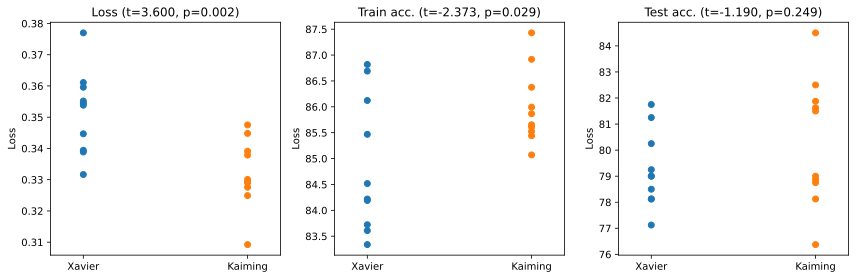

In [50]:
num_avg = 5
final_loss = {'Xavier': np.mean(net_dict['Xavier']['losses'][:,-num_avg:], axis=1), 'Kaiming': np.mean(net_dict['Kaiming']['losses'][:,-num_avg:], axis=1)}
final_train_acc = {'Xavier': np.mean(net_dict['Xavier']['trainAcc'][:,-num_avg:], axis=1), 'Kaiming': np.mean(net_dict['Kaiming']['trainAcc'][:,-num_avg:], axis=1)}
final_test_acc = {'Xavier': np.mean(net_dict['Xavier']['testAcc'][:,-num_avg:], axis=1), 'Kaiming': np.mean(net_dict['Kaiming']['testAcc'][:,-num_avg:], axis=1)}

# Plot final losses and accuracies
fig,axs = plt.subplots(1,3,figsize=(12,4))

for init_type in net_dict.keys():    
    categories = [init_type]*len(final_train_acc[init_type])
    xlim = [-0.2, 1.2]

    axs[0].scatter(categories, final_loss[init_type])
    axs[0].set_xlim(xlim)
    axs[0].set_ylabel('Loss')
    
    axs[1].scatter(categories, final_train_acc[init_type])
    
    axs[1].set_xlim(xlim)
    axs[1].set_ylabel('Loss')
    
    axs[2].scatter(categories, final_test_acc[init_type])
    axs[2].set_xlim(xlim)
    axs[2].set_ylabel('Loss')

titles_list = ['Loss', 'Train acc.', 'Test acc.']
attr_name = ['final_loss', 'final_train_acc', 'final_test_acc']
for i, a in enumerate(axs.flatten()):
    val_X = eval(attr_name[i])['Xavier']
    val_K = eval(attr_name[i])['Kaiming']
    t,p = stats.ttest_ind(val_X, val_K)
    a.set_title(f'{titles_list[i]} (t={t:.3f}, p={p:.3f})')

fig.tight_layout()
plt.show()

# Additional explorations

In [ ]:
# 1) Adam usually works better than SGD with fewer training epochs. Does Adam also equalize the differences attributable
#    to weight initialization?
#
# 2) The discrepancy between training and test performance suggests that Kaiming initialization involved some overfitting.
#    What are some strategies you could employ to reduce overfitting?
# Answer: To reduce overfitting, following regularization startegies can be employed:
#   L1/L2 weights regularization, Dropout layers, Early stopping, Data augmentation, Cross-validation, Reduce model complexity, Batch normalization
#
# 3) The difference between X and K initialization is likely to increase with more weights. Change the number of units in
#    the hidden layers from 32 to 64.
#